# 3.2

Shape of observations: (15,)

PROBLEM 1.2: METROPOLIS-HASTINGS WITH GIBBS FOR UNKNOWN sigma_squared
Hyperparameters: ns = 0.01, sigma_squared_s = 4.0
Initial sigma_squared = 4.0
Running for M = 10000 iterations with 300 burn-in samples
Running Metropolis-Hastings with Gibbs sampling for unknown sigma_squared...
ns = 0.01, sigma2_s = 4.0
Initial sigma_squared = 4.0
  Completed 1000/10000 iterations, MCMC acceptance rate: 0.586, sigma_squared = 0.2674
  Completed 2000/10000 iterations, MCMC acceptance rate: 0.541, sigma_squared = 0.4642
  Completed 3000/10000 iterations, MCMC acceptance rate: 0.538, sigma_squared = 0.6575
  Completed 4000/10000 iterations, MCMC acceptance rate: 0.537, sigma_squared = 0.4546
  Completed 5000/10000 iterations, MCMC acceptance rate: 0.539, sigma_squared = 0.7179
  Completed 6000/10000 iterations, MCMC acceptance rate: 0.536, sigma_squared = 0.2431
  Completed 7000/10000 iterations, MCMC acceptance rate: 0.536, sigma_squared = 0.5990
  Completed 8000/10000 i

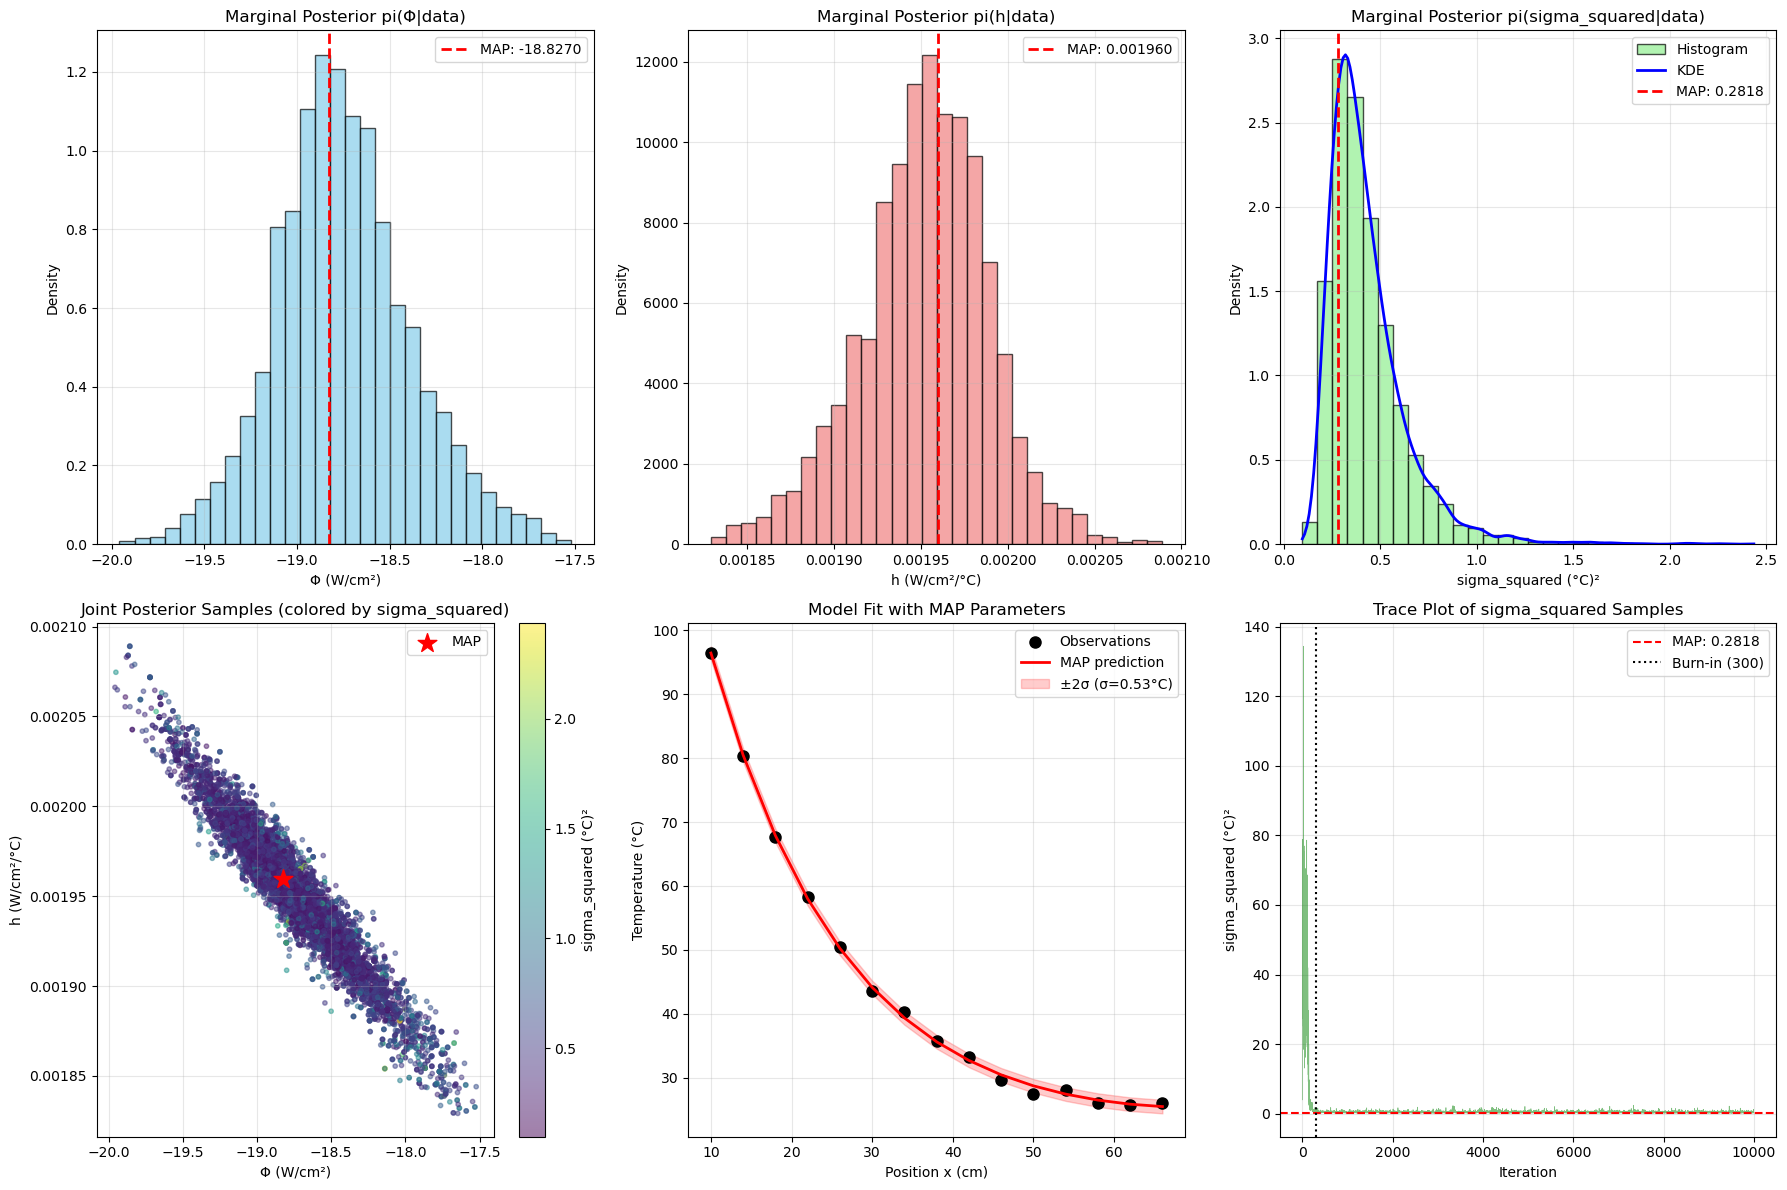

In [5]:
import os, sys, numpy as np, matplotlib.pyplot as plt
sys.path.append('../hw1')
import heat_rod as hr
from mcmc import *
from gibbs_mcmc import *
from scipy.io import loadmat

burnin = 300
samples_gibbs, s2_samples_gibbs, q_map_gibbs, s2_map_gibbs, posterior_values_gibbs, acc_rate_gibbs = run_metropolis_gibbs_for_heat_equation(M=10000, burnin=burnin)

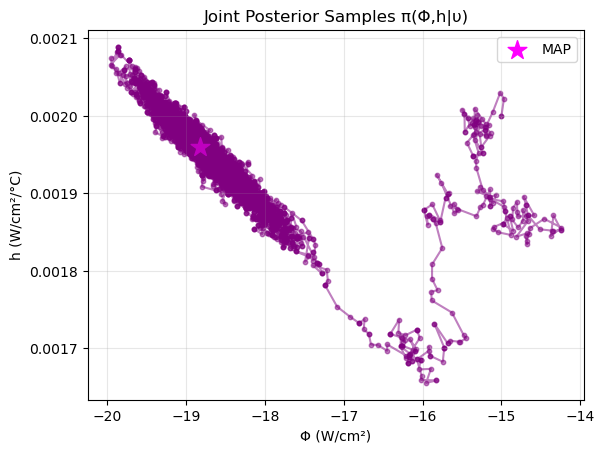

In [6]:
plt.scatter(samples_gibbs[:, 0], samples_gibbs[:, 1], alpha=0.5, c='purple', s=10)
plt.plot(samples_gibbs[:, 0], samples_gibbs[:, 1], alpha=0.5, c='purple')

plt.scatter(q_map_gibbs[0], q_map_gibbs[1], color='magenta', s=200, marker='*', label='MAP')

plt.xlabel('Φ (W/cm²)')
plt.ylabel('h (W/cm²/°C)')
plt.title('Joint Posterior Samples π(Φ,h|υ)')
plt.legend()
plt.grid(True, alpha=0.3)

#### removing burn-in

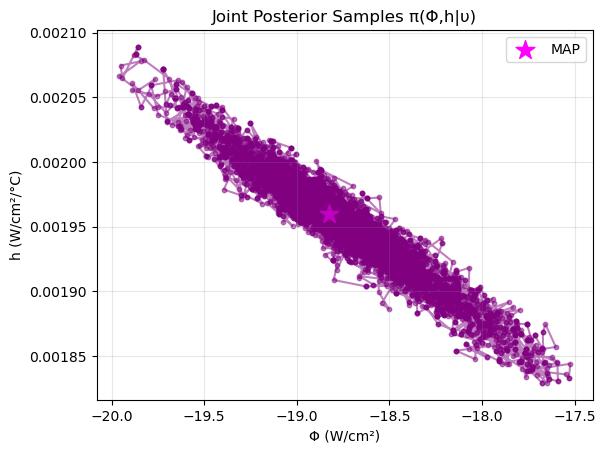

In [8]:
plt.scatter(samples_gibbs[burnin:, 0], samples_gibbs[burnin:, 1], alpha=0.5, c='purple', s=10)
plt.plot(samples_gibbs[burnin:, 0], samples_gibbs[burnin:, 1], alpha=0.5, c='purple')

plt.scatter(q_map_gibbs[0], q_map_gibbs[1], color='magenta', s=200, marker='*', label='MAP')

plt.xlabel('Φ (W/cm²)')
plt.ylabel('h (W/cm²/°C)')
plt.title('Joint Posterior Samples π(Φ,h|υ)')
plt.legend()
plt.grid(True, alpha=0.3)

###
$q_{MAP, Gibbs} =  [-18.83 W/cm²;
  h = 0.00196 W/cm²/°C]$ with $\sigma^2 = 0.282 (°C)²$ after removing 300 burn-in samples. 

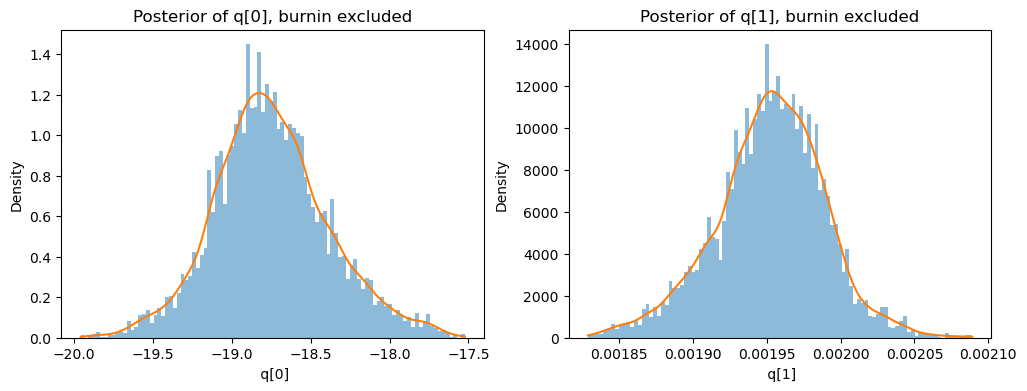

In [10]:
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    s = samples_gibbs[burnin:, i] ####TODO: BURNIN INCLUDED?
    
    # Histogram
    axes[i].hist(s, bins=100, density=True, alpha=0.5)
    
    # KDE smooth curve
    kde = gaussian_kde(s)
    x = np.linspace(min(s), max(s), 300)
    axes[i].plot(x, kde(x))
    
    axes[i].set_title(f"Posterior of q[{i}], burnin excluded")
    axes[i].set_xlabel(f" q[{i}]")
    axes[i].set_ylabel("Density")

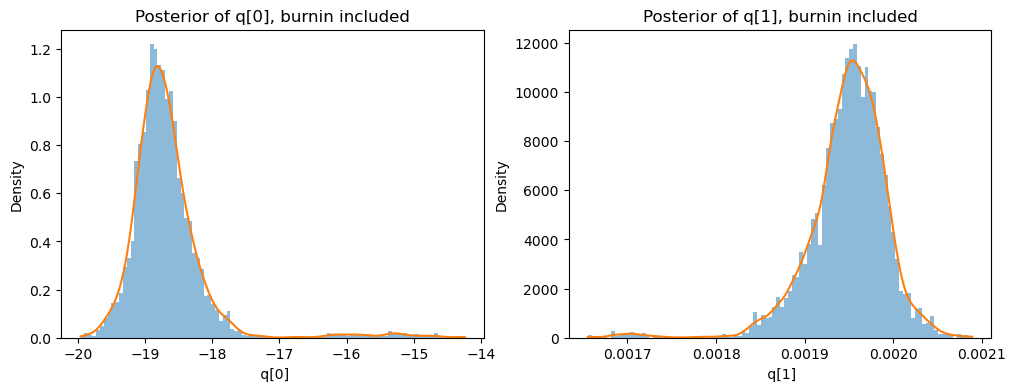

In [11]:
from scipy.stats import gaussian_kde
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    s = samples_gibbs[:, i] ####TODO: BURNIN INCLUDED?
    
    # Histogram
    axes[i].hist(s, bins=100, density=True, alpha=0.5)
    
    # KDE smooth curve
    kde = gaussian_kde(s)
    x = np.linspace(min(s), max(s), 300)
    axes[i].plot(x, kde(x))
    
    axes[i].set_title(f"Posterior of q[{i}], burnin included")
    axes[i].set_xlabel(f" q[{i}]")
    axes[i].set_ylabel("Density")

Note: q[0] is $\phi$, while q[1] is $h$.

The exclusion of burn-in samples leads to more symmetric distributions because the early iterations of the MCMC chain are heavily influenced by the initial starting point and have not yet converged to the true posterior distribution. During burn-in, the chain is still "warming up" and exploring regions far from the high-probability area, often exhibiting transient behavior, high autocorrelation, and directional drift as it moves from the initial guess toward the stationary distribution. These early samples tend to be biased toward one side of the posterior (depending on the starting location) and can skew the histogram, creating asymmetry and heavier tails. Once these non-representative samples are removed, the remaining samples are drawn from a more stationary distribution where the chain has reached equilibrium and is properly sampling around the true posterior mode. This equilibrium sampling produces a more symmetric distribution that better reflects the actual uncertainty in the parameters, as the chain has now explored the parameter space in a balanced manner without the directional bias inherent in the transient phase.

# 3.3


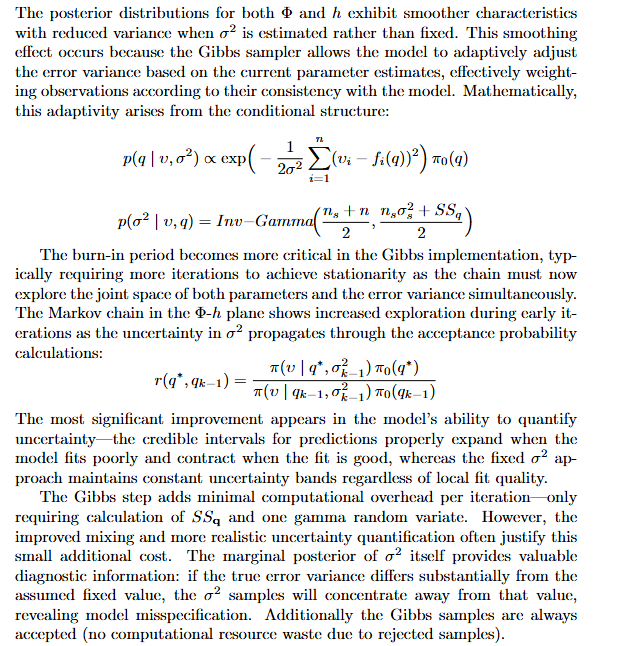
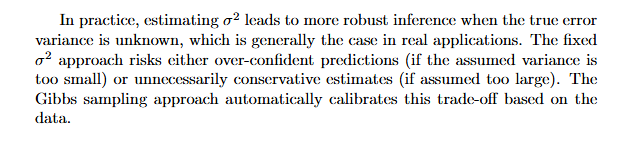